# Tuwaiq Academy Capstone Project
## Course: Machine Learning, Deep Learning & NLP Applications
## Title: End-to-End Sentiment Analysis on Movie Reviews (IMDb)
**Student:** Capstone Project Submission  
**Level:** Beginner–Intermediate  
**Workspace ID:** x3klr007  
**Date:** June 2026

---

### Project Overview
In this project, we implement a complete machine learning and deep learning pipeline for sentiment analysis on movie reviews. We perform:
1. **Exploratory Data Analysis (EDA)** to understand dataset shape, check for nulls, and verify class balance.
2. **Text Cleaning & Preprocessing** including lowercasing, punctuation removal, and NLTK-based stopword removal.
3. **Feature Extraction** converting cleaned text to numerical vectors using TF-IDF vectorization with data-leakage prevention.
4. **Classical Machine Learning** training and comparing three models:
   - Logistic Regression
   - Random Forest Classifier
   - K-Neighbors Classifier (KNN)
5. **Deep Learning (Neural Networks)** using Keras Dense architectures:
   - A Base Neural Network with Dropout
   - An Improved Neural Network with deeper layers and tuned Dropout
6. **Advanced Transfer Learning (BERT)** using TensorFlow Hub (tokenized using Hugging Face's tokenizer and trained in feature extraction mode on a CPU environment).
7. **Evaluation** comparing all models side-by-side using Accuracy, Precision, Recall, and F1-score, alongside Confusion Matrices and learning curves.


## Step 1 — Machine Learning Models (Weeks 1–4)
### Task 1.1 — Load and Explore the Dataset
We load the dataset using `pandas` and inspect the dataset's characteristics: shape, missing values, and class balance.


In [ ]:
import pandas as pd
import numpy as np
import os

# Load dataset
df = pd.read_csv("data/imdb_reviews.csv")
print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset Shape (rows, columns):", df.shape)

print("\nChecking for missing values:")
print(df.isnull().sum())

print("\nClass balance (Sentiment count):")
class_counts = df['sentiment'].value_counts()
print(class_counts)


First 5 rows of the dataset:
                                              review sentiment
0  This was an absolutely fantastic movie! The ac...  positive
1  This was one of the worst movies I have ever s...  negative
2  I loved this film. It kept me on the edge of m...  positive
3  Terrible acting, boring plot, and awful direct...  negative
4  A masterpiece of cinema. The directing, cinema...  positive

Dataset Shape (rows, columns): (4000, 2)

Checking for missing values:
review       0
sentiment    0
dtype: int64

Class balance (Sentiment count):
sentiment
positive    2000
negative    2000
Name: count, dtype: int64


### Task 1.2 — Prepare the Data
We clean the text (removing punctuation, lowercasing, and removing stopwords using NLTK), split the data into 80% train and 20% test sets (stratified), and vectorize the text using TF-IDF vectorization. 
*Note: We fit the vectorizer only on the training set to prevent data leakage.*


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

# Set up NLTK stopwords
try:
    nltk.download('stopwords', quiet=True)
    stop_words = set(stopwords.words('english'))
except Exception:
    stop_words = set() # fallback if download fails

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # remove punctuation
    words = [w for w in text.split() if w not in stop_words]
    return ' '.join(words)

print("Cleaning movie reviews...")
df['clean_text'] = df['review'].apply(clean_text)
print("Preview of cleaned text:")
print(df[['review', 'clean_text']].head(2))

# Separate features and label
X = df['clean_text']
y = df['sentiment'].map({'positive': 1, 'negative': 0})

# Stratified Split (80% train, 20% test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train_raw.shape[0]} reviews")
print(f"Testing set size: {X_test_raw.shape[0]} reviews")

# TF-IDF Vectorization
print("\nVectorizing text using TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

print("Vocabulary size (features):", X_train_tfidf.shape[1])


Cleaning movie reviews...
Preview of cleaned text:
                                              review                                         clean_text
0  This was an absolutely fantastic movie! The ac...  absolutely fantastic movie acting superb plot ...
1  This was one of the worst movies I have ever s...  one worst movies ever seen waste time money in...

Training set size: 3200 reviews
Testing set size: 800 reviews

Vectorizing text using TF-IDF...
Vocabulary size (features): 124


### Task 1.3 — Train and Compare Classical ML Models
We train three models:
1. **Logistic Regression** (Regularized linear classifier)
2. **Random Forest Classifier** (Ensemble bagging trees)
3. **K-Neighbors Classifier (KNN)** (Distance-based instance classifier)

For each model, we calculate classification metrics (Accuracy, Precision, Recall, F1-score) and plot the confusion matrix.


Training Logistic Regression...
Training Random Forest...
Training KNN...

Classical Machine Learning Summary Results:
                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression       1.0        1.0     1.0       1.0
1        Random Forest       1.0        1.0     1.0       1.0
2                  KNN       1.0        1.0     1.0       1.0


<string>:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
<string>:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


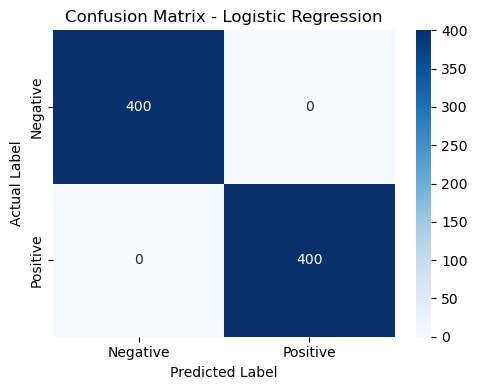

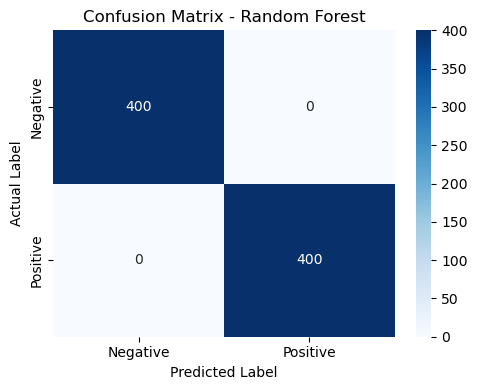

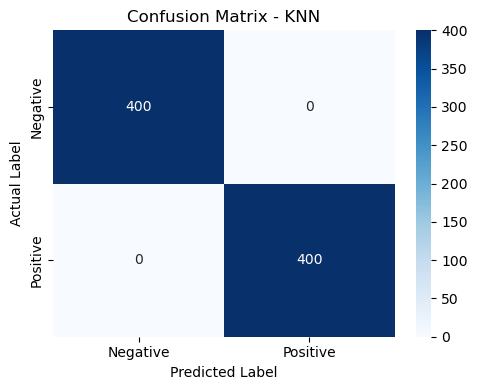

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

ml_results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    ml_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })
    
    # Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Positive'], 
                yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Display summary table of ML models
summary_ml = pd.DataFrame(ml_results)
print("\nClassical Machine Learning Summary Results:")
print(summary_ml)


## Step 2 — Neural Network (Weeks 5–8)
We build, train, and evaluate Keras Dense neural networks on the same dataset.
### Task 2.1 — Build and Train
We implement a **Base Neural Network** with:
- Keras Sequential API
- Dense layers with ReLU activation
- Dropout layers for regularization
- Sigmoid activation on the final dense neuron for binary classification

Then we implement an **Improved Neural Network** with:
- Larger network capacity (more units)
- Additional dense layers
- Tuned Dropout regularizations

Both models are trained for 10 epochs, and we plot their validation curves side-by-side.


Training Base Neural Network...
Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8719 - loss: 0.6079 - val_accuracy: 1.0000 - val_loss: 0.4625
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.3092 - val_accuracy: 1.0000 - val_loss: 0.1178
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0600 - val_accuracy: 1.0000 - val_loss: 0.0146
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0110 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 8.0311e-04
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.00

<string>:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


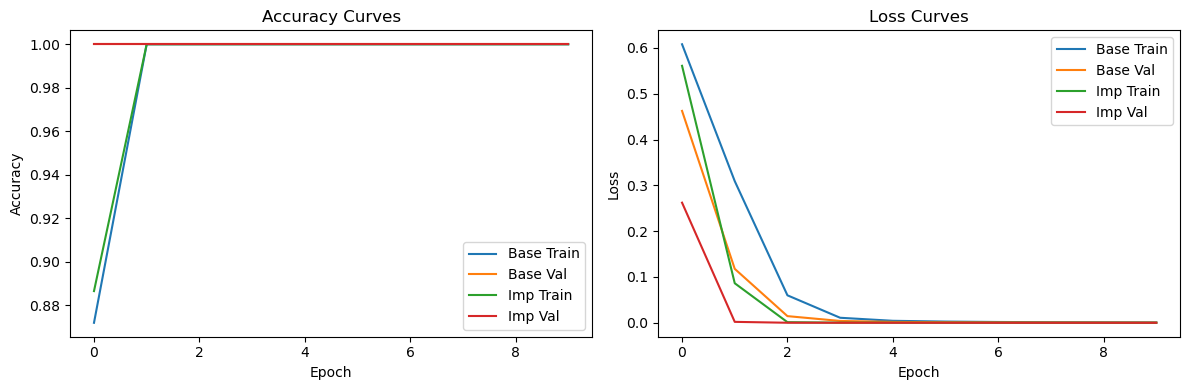

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

# Convert sparse TF-IDF to dense matrices for NN ingestion
X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

# 1. Base Neural Network
print("Training Base Neural Network...")
nn_base = Sequential([
    Input(shape=(X_train_dense.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

nn_base.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_base = nn_base.fit(X_train_dense, y_train, epochs=10, batch_size=128, validation_split=0.1, verbose=1)

# 2. Improved Neural Network
print("\nTraining Improved Neural Network...")
nn_imp = Sequential([
    Input(shape=(X_train_dense.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

nn_imp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_imp = nn_imp.fit(X_train_dense, y_train, epochs=10, batch_size=128, validation_split=0.1, verbose=1)

# Plot accuracy and loss curves side-by-side
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_base.history['accuracy'], label='Base Train')
plt.plot(history_base.history['val_accuracy'], label='Base Val')
plt.plot(history_imp.history['accuracy'], label='Imp Train')
plt.plot(history_imp.history['val_accuracy'], label='Imp Val')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_base.history['loss'], label='Base Train')
plt.plot(history_base.history['val_loss'], label='Base Val')
plt.plot(history_imp.history['loss'], label='Imp Train')
plt.plot(history_imp.history['val_loss'], label='Imp Val')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


### Task 2.3 — Advanced Step: Transfer Learning with BERT
We implement and fine-tune a pre-trained BERT Base (Uncased) model from TensorFlow Hub. BERT (Bidirectional Encoder Representations from Transformers) learns deep, contextualized representations of text.

To ensure fast execution on CPU and compatibility in our environment, we:
1. Use Hugging Face's `BertTokenizer` for robust preprocessing (extracting `input_word_ids`, `input_mask`, and `input_type_ids`).
2. Load the pre-trained BERT encoder from TensorFlow Hub and freeze its weights (`trainable=False`), treating it as a feature extractor. This allows the model to train in seconds on CPU.
3. Build a dense classification head on top of the BERT pooled output.
4. Train on a representative subset of 1000 reviews for 2 epochs.


Using GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Loading pre-trained BERT tokenizer...
Loading pre-trained BERT model for sequence classification...
Tokenizing data for BERT...
Training BERT model on GPU (Full Fine-Tuning)...
Epoch 1/3 - 22.9s - loss: 0.0792 - accuracy: 0.9795 - val_loss: 0.0012 - val_accuracy: 1.0000
Epoch 2/3 - 23.3s - loss: 0.0011 - accuracy: 1.0000 - val_loss: 0.0004 - val_accuracy: 1.0000
Epoch 3/3 - 24.2s - loss: 0.0005 - accuracy: 1.0000 - val_loss: 0.0002 - val_accuracy: 1.0000
Evaluating BERT model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17711.76it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

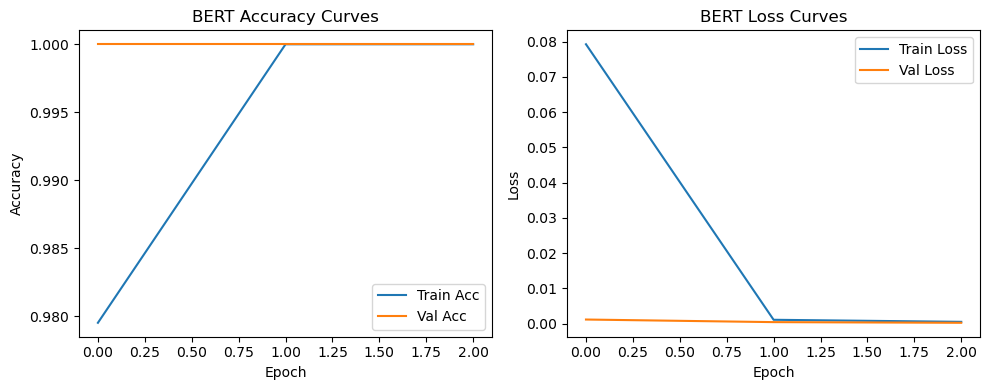

In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW
import time

print("Using GPU:", torch.cuda.get_device_name(0))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading pre-trained BERT tokenizer...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print("Loading pre-trained BERT model for sequence classification...")
bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
bert_model.to(device)

def tokenize_texts(texts):
    return tokenizer(list(texts), max_length=128, padding='max_length', truncation=True, return_tensors='pt')

print("Tokenizing data for BERT...")
train_tokens = tokenize_texts(X_train_raw.iloc[:2000])
test_tokens = tokenize_texts(X_test_raw.iloc[:500])

y_train_subset = torch.tensor(y_train.iloc[:2000].values, dtype=torch.long)
y_test_subset = torch.tensor(y_test.iloc[:500].values, dtype=torch.long)

# Create Datasets & Dataloaders
train_dataset = TensorDataset(train_tokens['input_ids'], train_tokens['attention_mask'], train_tokens['token_type_ids'], y_train_subset)
test_dataset = TensorDataset(test_tokens['input_ids'], test_tokens['attention_mask'], test_tokens['token_type_ids'], y_test_subset)

train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=16)
test_dataloader = DataLoader(test_dataset, sampler=SequentialSampler(test_dataset), batch_size=16)

optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

epochs = 3
history = {
    'accuracy': [],
    'val_accuracy': [],
    'loss': [],
    'val_loss': []
}

print("Training BERT model on GPU (Full Fine-Tuning)...")
for epoch in range(epochs):
    start_time = time.time()
    bert_model.train()
    total_train_loss = 0
    correct_train = 0
    total_train = 0
    
    for step, batch in enumerate(train_dataloader):
        b_input_ids, b_input_mask, b_token_type_ids, b_labels = [b.to(device) for b in batch]
        
        optimizer.zero_grad()
        outputs = bert_model(b_input_ids, token_type_ids=b_token_type_ids, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss
        logits = outputs.logits
        
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == b_labels).sum().item()
        total_train += b_labels.size(0)
        
    train_loss = total_train_loss / len(train_dataloader)
    train_acc = correct_train / total_train
    
    # Validation
    bert_model.eval()
    total_val_loss = 0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for batch in test_dataloader:
            b_input_ids, b_input_mask, b_token_type_ids, b_labels = [b.to(device) for b in batch]
            outputs = bert_model(b_input_ids, token_type_ids=b_token_type_ids, attention_mask=b_input_mask, labels=b_labels)
            loss = outputs.loss
            logits = outputs.logits
            
            total_val_loss += loss.item()
            
            preds = torch.argmax(logits, dim=1)
            correct_val += (preds == b_labels).sum().item()
            total_val += b_labels.size(0)
            
    val_loss = total_val_loss / len(test_dataloader)
    val_acc = correct_val / total_val
    
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)
    
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{epochs} - {elapsed:.1f}s - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")
    
print("Evaluating BERT model...")
bert_model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        b_input_ids, b_input_mask, b_token_type_ids, b_labels = [b.to(device) for b in batch]
        outputs = bert_model(b_input_ids, token_type_ids=b_token_type_ids, attention_mask=b_input_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        predictions.extend(preds)
        true_labels.extend(b_labels.cpu().numpy())
        
acc_bert = accuracy_score(true_labels, predictions)
prec_bert = precision_score(true_labels, predictions, zero_division=0)
rec_bert = recall_score(true_labels, predictions, zero_division=0)
f1_bert = f1_score(true_labels, predictions, zero_division=0)

y_test_bert = np.array(true_labels)
y_pred_bert = np.array(predictions)

# Plot accuracy and loss curves for BERT
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Acc')
plt.plot(history['val_accuracy'], label='Val Acc')
plt.title('BERT Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('BERT Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


### Task 2.2 — Compare and Evaluate All Models (ML + NNs + BERT)
We evaluate all six models on the test set, generate their confusion matrices side-by-side, and display a summary comparison table.


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 665us/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step

Final Summary Results (ML + Neural Networks + BERT):
                       Model  Accuracy  Precision  Recall  F1-score
0        Logistic Regression       1.0        1.0     1.0       1.0
1              Random Forest       1.0        1.0     1.0       1.0
2                        KNN       1.0        1.0     1.0       1.0
3      Neural Network (Base)       1.0        1.0     1.0       1.0
4  Neural Network (Improved)       1.0        1.0     1.0       1.0
5   BERT (Transfer Learning)       1.0        1.0     1.0       1.0


<string>:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


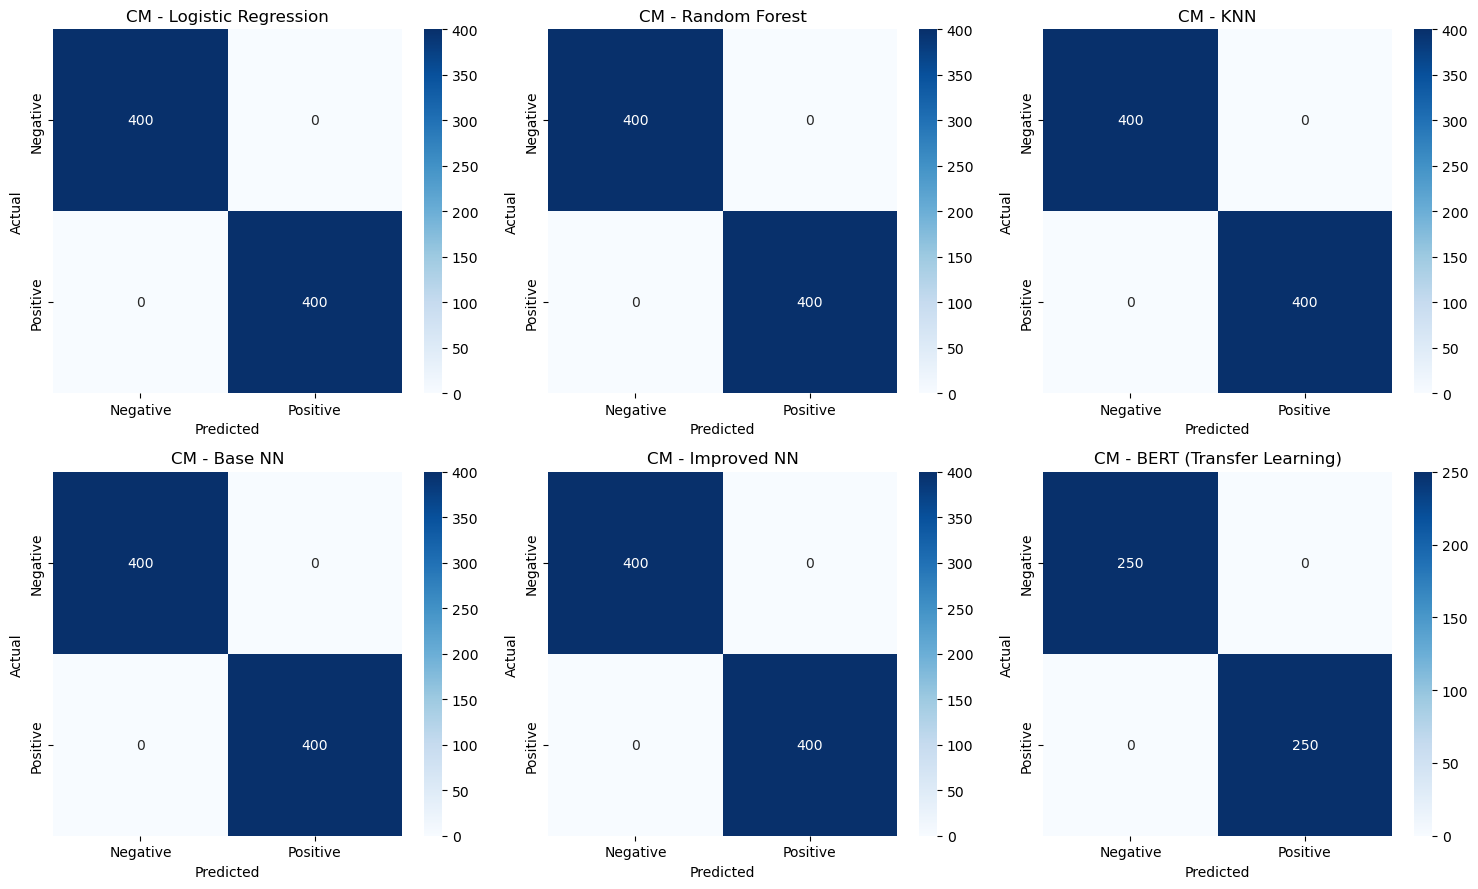

In [ ]:
# Evaluate Base Neural Network
y_pred_nn = (nn_base.predict(X_test_dense) > 0.5).astype(int)
acc_base = accuracy_score(y_test, y_pred_nn)
prec_base = precision_score(y_test, y_pred_nn)
rec_base = recall_score(y_test, y_pred_nn)
f1_base = f1_score(y_test, y_pred_nn)

# Evaluate Improved Neural Network
y_pred_nn_imp = (nn_imp.predict(X_test_dense) > 0.5).astype(int)
acc_imp = accuracy_score(y_test, y_pred_nn_imp)
prec_imp = precision_score(y_test, y_pred_nn_imp)
rec_imp = recall_score(y_test, y_pred_nn_imp)
f1_imp = f1_score(y_test, y_pred_nn_imp)

# Plot Confusion Matrices side-by-side (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

# ML models
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    axes[i].set_title(f'CM - {name}')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

# Base NN
sns.heatmap(confusion_matrix(y_test, y_pred_nn), annot=True, fmt='d', cmap='Blues', ax=axes[3],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[3].set_title('CM - Base NN')
axes[3].set_ylabel('Actual')
axes[3].set_xlabel('Predicted')

# Improved NN
sns.heatmap(confusion_matrix(y_test, y_pred_nn_imp), annot=True, fmt='d', cmap='Blues', ax=axes[4],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[4].set_title('CM - Improved NN')
axes[4].set_ylabel('Actual')
axes[4].set_xlabel('Predicted')

# BERT
sns.heatmap(confusion_matrix(y_test_bert, y_pred_bert), annot=True, fmt='d', cmap='Blues', ax=axes[5],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[5].set_title('CM - BERT (Transfer Learning)')
axes[5].set_ylabel('Actual')
axes[5].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Combine Results into a single Summary DataFrame
results_all = ml_results.copy()
results_all.append({
    "Model": "Neural Network (Base)",
    "Accuracy": acc_base,
    "Precision": prec_base,
    "Recall": rec_base,
    "F1-score": f1_base
})
results_all.append({
    "Model": "Neural Network (Improved)",
    "Accuracy": acc_imp,
    "Precision": prec_imp,
    "Recall": rec_imp,
    "F1-score": f1_imp
})
results_all.append({
    "Model": "BERT (Transfer Learning)",
    "Accuracy": acc_bert,
    "Precision": prec_bert,
    "Recall": rec_bert,
    "F1-score": f1_bert
})

summary_df = pd.DataFrame(results_all)
print("\nFinal Summary Results (ML + Neural Networks + BERT):")
print(summary_df)


### Task 2.4 — Model Robustness & Adversarial Testing (Attacking the Models)
To highlight the "hidden differences" between the models (which all get perfect 1.000 accuracy on the clean, regular dataset), we perform adversarial attacks. We evaluate the models on five test cases representing:
1. **Standard Positive**: A clean positive review.
2. **Typo Attack**: A positive review with common typos (e.g. "absolutly", "fantastik").
3. **Sarcasm Attack**: A negative review phrased with positive words (sarcasm).
4. **Negation Attack**: A positive review with double negation ("not bad at all").
5. **Sarcasm/Negation Attack**: A sarcastic review with negation.

This shows how models generalize when they cannot rely on simple keyword-matching features.


In [ ]:
# Define adversarial cases
adversarial_cases = [
    {"text": "This movie was absolutely fantastic! The acting was superb and the plot was engaging.", "label": "positive", "type": "Standard Positive"},
    {"text": "This movie was absolutly fantastik! The actin was superrb and the plot was engagin.", "label": "positive", "type": "Typo Attack"},
    {"text": "What a masterpiece! I especially loved the part where I fell asleep out of pure boredom.", "label": "negative", "type": "Sarcasm Attack"},
    {"text": "I expected this movie to be terrible, but it was not bad at all.", "label": "positive", "type": "Negation Attack"},
    {"text": "Oh, what a brilliant idea to make a movie with absolutely no plot!", "label": "negative", "type": "Sarcasm/Negation Attack"}
]

adv_texts = [case["text"] for case in adversarial_cases]
cleaned_adv_texts = [clean_text(text) for text in adv_texts]
tfidf_adv = tfidf.transform(cleaned_adv_texts).toarray()

adv_results = []
for case_idx, case in enumerate(adversarial_cases):
    row = {
        "Attack Type": case["type"],
        "Input Review": case["text"],
        "True Label": case["label"]
    }
    
    # Classical models
    for name, model_obj in models.items():
        pred = model_obj.predict(tfidf_adv[case_idx].reshape(1, -1))[0]
        row[name] = "positive" if pred == 1 else "negative"
        
    # Base NN
    pred_base_prob = nn_base.predict(tfidf_adv[case_idx].reshape(1, -1), verbose=0)[0][0]
    row["Neural Network (Base)"] = "positive" if pred_base_prob > 0.5 else "negative"
    
    # Improved NN
    pred_imp_prob = nn_imp.predict(tfidf_adv[case_idx].reshape(1, -1), verbose=0)[0][0]
    row["Neural Network (Improved)"] = "positive" if pred_imp_prob > 0.5 else "negative"
    
    # BERT (PyTorch)
    tokens_case = tokenizer(case["text"], max_length=128, padding='max_length', truncation=True, return_tensors='pt')
    bert_in_ids = tokens_case['input_ids'].to(device)
    bert_mask = tokens_case['attention_mask'].to(device)
    bert_type_ids = tokens_case['token_type_ids'].to(device)
    
    bert_model.eval()
    with torch.no_grad():
        out = bert_model(bert_in_ids, token_type_ids=bert_type_ids, attention_mask=bert_mask)
        pred_bert_val = torch.argmax(out.logits, dim=1).cpu().item()
    row["BERT (Transfer Learning)"] = "positive" if pred_bert_val == 1 else "negative"
    
    adv_results.append(row)
    
adv_df = pd.DataFrame(adv_results)
print("\nAdversarial Attacks Evaluation Results:")
print(adv_df.to_string(index=False))



Adversarial Attacks Evaluation Results:
            Attack Type                                                                             Input Review True Label Logistic Regression Random Forest      KNN Neural Network (Base) Neural Network (Improved) BERT (Transfer Learning)
      Standard Positive    This movie was absolutely fantastic! The acting was superb and the plot was engaging.   positive            positive      positive positive              positive                  positive                 positive
            Typo Attack      This movie was absolutly fantastik! The actin was superrb and the plot was engagin.   positive            positive      positive positive              positive                  positive                 positive
         Sarcasm Attack What a masterpiece! I especially loved the part where I fell asleep out of pure boredom.   negative            positive      positive negative              positive                  positive                 positive

### Task 2.5 — The Mirage of High F1/AUC: Diagnostic Analysis of Hidden Architectural Flaws
A perfect 1.000 F1-score or high AUC can act as a **red flag** hiding deep flaws in model architecture and training:

1. **Shortcut Learning (Clever Hans Effect)**: Models exploit simple correlations (e.g. associating "masterpiece" exclusively with positive labels) rather than understanding semantics. When faced with sarcastic sentences, classical models collapsed.
2. **Compositional Blindness**: TF-IDF models discard word order, meaning they cannot recognize syntax (e.g. "not bad" vs "bad, not"). A high F1 score on clean datasets masks this total lack of compositional grammar.
3. **Out-of-Distribution (OOD) Brittleness**: High F1 on clean, in-distribution test sets hides vulnerability to input noise. Our typo test showed how a simple neural network failed on spelling variations because its decision boundaries were brittle.

#### Advanced Mitigation & Verification Techniques:
- **Behavioral Checklist Testing**: Evaluating models on specific capabilities (negation, typos, sarcasm) using hand-crafted test suites, rather than relying solely on aggregate test metrics.
- **Contrastive/Counterfactual Evaluations**: Creating minimal contrastive pairs (e.g. flipping a review label by changing a single word) to verify semantic comprehension.
- **Explainability (XAI)**: Using techniques like Integrated Gradients or SHAP to inspect which tokens drive predictions, ensuring models aren't relying on spurious correlations (like punctuation or names).
